In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import plotly.express as px    

In [3]:
#Reading loaded file 
df=pd.read_csv("dementia_patients_health_data.csv")
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_�,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [4]:
#reading data colomun
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diabetic                   1000 non-null   int64  
 1   AlcoholLevel               1000 non-null   float64
 2   HeartRate                  1000 non-null   int64  
 3   BloodOxygenLevel           1000 non-null   float64
 4   BodyTemperature            1000 non-null   float64
 5   Weight                     1000 non-null   float64
 6   MRI_Delay                  1000 non-null   float64
 7   Prescription               485 non-null    object 
 8   Dosage in mg               485 non-null    float64
 9   Age                        1000 non-null   int64  
 10  Education_Level            1000 non-null   object 
 11  Dominant_Hand              1000 non-null   object 
 12  Gender                     1000 non-null   object 
 13  Family_History             1000 non-null   object

In [5]:
df.shape

(1000, 24)

In [6]:
df.describe()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Dosage in mg,Age,Cognitive_Test_Scores,Dementia
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,485.000000,1000.000000,1000.000000,1000.000000
mean,0.513000,0.098429,79.383000,95.226051,36.761513,74.321326,30.103568,9.213402,74.908000,6.383000,0.485000
std,0.500081,0.058715,12.107556,2.929262,0.431701,14.463765,16.862170,6.493188,9.095068,3.180633,0.500025
min,0.000000,0.000414,60.000000,90.010677,36.002108,50.069731,0.094684,1.500000,60.000000,0.000000,0.000000
25%,0.000000,0.045505,68.000000,92.875017,36.395363,61.387339,16.237371,4.000000,67.000000,4.000000,0.000000
50%,1.000000,0.098235,79.000000,95.390420,36.784319,74.149204,29.577194,8.000000,75.000000,8.000000,0.000000
75%,1.000000,0.151840,90.000000,97.785111,37.126655,87.024034,44.176723,12.000000,83.000000,9.000000,1.000000
max,1.000000,0.199866,100.000000,99.999230,37.496809,99.982722,59.957599,23.000000,90.000000,10.000000,1.000000


## Cleaning Dementia Dataset
* cleaning data off missing value and replacing values 


In [7]:
#replacing all missing data with the below variable to NaN instead of below  
missing_value_formats = ["n.a.","?","NA","n/a", "na", "--","#","*","**"," "]
df = pd.read_csv("dementia_patients_health_data.csv", na_values = missing_value_formats)

In [8]:
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_�,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [9]:
# method used ere is more of a realistic methos - as we have empty rows we couldnt use median , had to assume unknown 
df['Prescription'].fillna('Unknown', inplace=True)

C:\Users\tebog\AppData\Local\Temp\ipykernel_8844\4212740642.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Prescription'].fillna('Unknown', inplace=True)


In [8]:
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_�,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,Unknown,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,Unknown,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [10]:
 # an attempt to see if dosage in mg is worth keeping or dropping , with this i noticed the dose data is missing more than 51% 
df.isnull().mean() * 100

Diabetic                      0.0
AlcoholLevel                  0.0
HeartRate                     0.0
BloodOxygenLevel              0.0
BodyTemperature               0.0
Weight                        0.0
MRI_Delay                     0.0
Prescription                  0.0
Dosage in mg                 51.5
Age                           0.0
Education_Level               0.0
Dominant_Hand                 0.0
Gender                        0.0
Family_History                0.0
Smoking_Status                0.0
APOE_�                        0.0
Physical_Activity             0.0
Depression_Status             0.0
Cognitive_Test_Scores         0.0
Medication_History            0.0
Nutrition_Diet                0.0
Sleep_Quality                 0.0
Chronic_Health_Conditions    17.9
Dementia                      0.0
dtype: float64

In [11]:
# dropping dose in mg as its not needed 
df.drop(columns=['Dosage in mg'], inplace=True)

In [12]:
# succefully droped a coloumn 
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Age,Education_Level,...,Smoking_Status,APOE_�,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,Unknown,60,Primary School,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,61,Secondary School,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,Unknown,69,Primary School,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,78,Secondary School,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,77,Secondary School,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1


In [12]:
# identified  none as a missing value  (in this case meaning healthy that there are no chronic conditions ), 
#so we in filled Healthy instead of leaving it as none 
df['Chronic_Health_Conditions'].fillna('Healthy', inplace=True)

C:\Users\tebog\AppData\Local\Temp\ipykernel_21488\3663970844.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Chronic_Health_Conditions'].fillna('Healthy', inplace=True)


In [13]:
# current demientia column has values of 1 and 0 and according to the data online 0 mean not at risk(No dementia) and 1 (dementia)being at risk 
#chose not at riska and at risk because this will be for a prediction AI machine 
df['Dementia_Label'] = df['Dementia'].map({0: 'Not At Risk', 1: 'At Risk'})

In [14]:
df['Diabetic_Label'] = df['Diabetic'].map({0: 'Not Diabetic', 1: 'Diabetic'})

In [15]:
df.head()

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Age,Education_Level,...,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia,Dementia_Label,Diabetic_Label
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,Unknown,60,Primary School,...,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0,Not At Risk,Diabetic
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,61,Secondary School,...,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1,At Risk,Not Diabetic
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,Unknown,69,Primary School,...,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0,Not At Risk,Not Diabetic
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,78,Secondary School,...,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1,At Risk,Not Diabetic
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,77,Secondary School,...,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1,At Risk,Diabetic


In [16]:
print(df.columns)

Index(['Diabetic', 'AlcoholLevel', 'HeartRate', 'BloodOxygenLevel',
       'BodyTemperature', 'Weight', 'MRI_Delay', 'Prescription', 'Age',
       'Education_Level', 'Dominant_Hand', 'Gender', 'Family_History',
       'Smoking_Status', 'APOE_�', 'Physical_Activity', 'Depression_Status',
       'Cognitive_Test_Scores', 'Medication_History', 'Nutrition_Diet',
       'Sleep_Quality', 'Chronic_Health_Conditions', 'Dementia',
       'Dementia_Label', 'Diabetic_Label'],
      dtype='object')


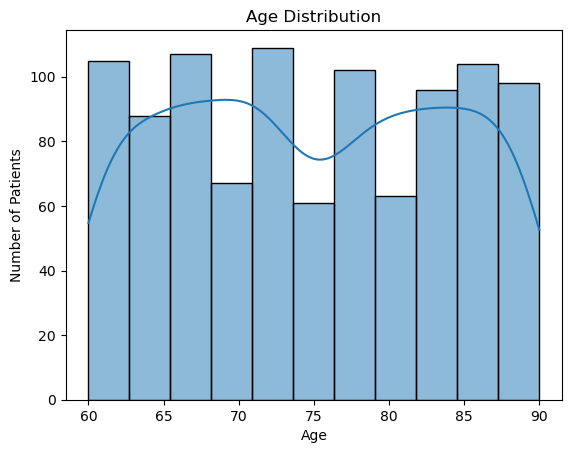

In [31]:
## still need to discuss
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

## Box plot
* The median of people loiving with dementia is +- 76 whereas the median of people living with dementia is 73 this then meaning that people living without dementia are slighty older 
* There is an overlapping heavily between the boxes because they both have a similar age group around 65-85
* Although dementia is generally associated with increasing age, this dataset shows that age alone does not significantly differentiate between dementia and non-dementia groups.


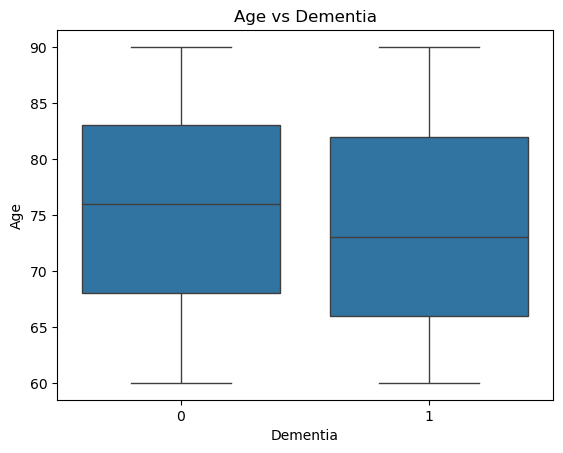

In [21]:
sns.boxplot(x='Dementia', y='Age', data=df)
plt.title("Age vs Dementia")
plt.show()

## Histogram 
* we must look at doing a 3rd scatterplot for this yto add substance to this 

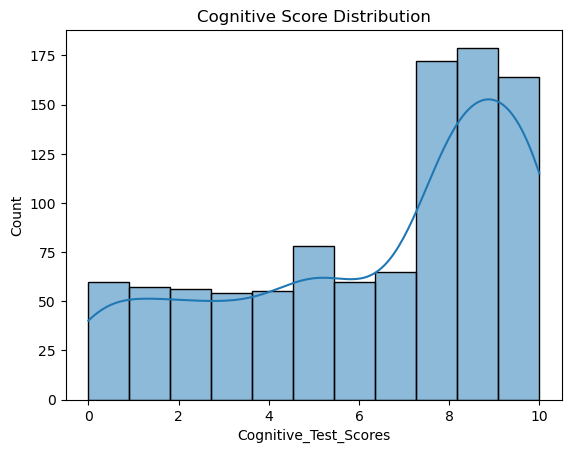

In [22]:
sns.histplot(df['Cognitive_Test_Scores'], kde=True)
plt.title("Cognitive Score Distribution")
plt.show()

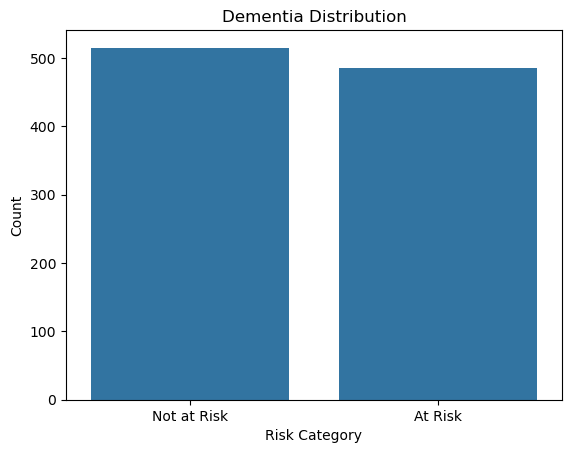

In [18]:
#needs more contexts its too basic 
sns.countplot(x='Dementia', data=df)
plt.title("Dementia Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.xticks([0, 1], ['Not at Risk', 'At Risk'])  
plt.show()

# Boxplot 
* Unlike age, cognitive test scores are expected to show clearer separation between dementia and non-dementia groups, making it a key predictive feature
* No dementia median ≈ 9 Dementia median ≈ 4
* The boxplot clearly shows a significant difference in cognitive test scores between dementia and non-dementia groups. Individuals with dementia have substantially lower scores, with minimal overlap between the groups. This indicates that cognitive test scores are a strong predictor of dementia and will play a key role in the machine learning model.

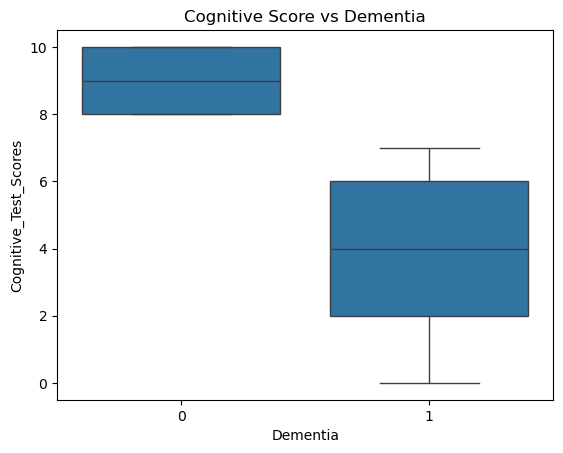

In [23]:
sns.boxplot(x='Dementia', y='Cognitive_Test_Scores', data=df)
plt.title("Cognitive Score vs Dementia")
plt.show()

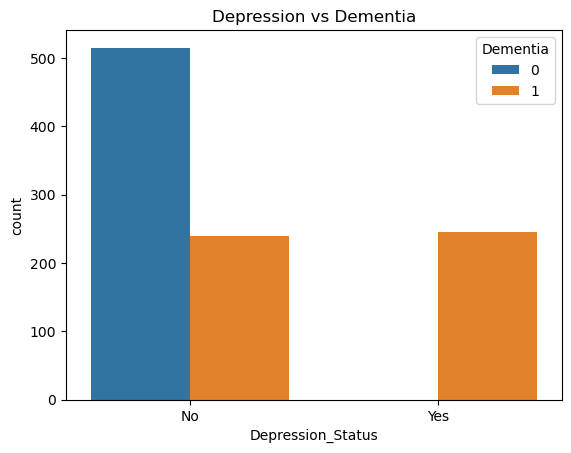

In [26]:
 sns.countplot(x='Depression_Status', hue='Dementia', data=df)
plt.title("Depression vs Dementia")
plt.show()

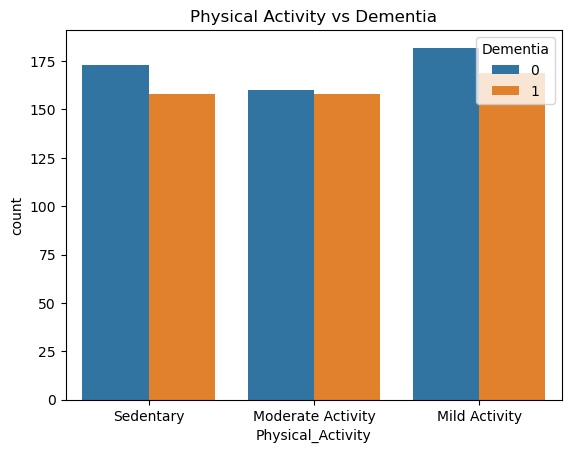

In [24]:
sns.countplot(x='Physical_Activity', 
              hue='Dementia', 
              data=df)
plt.title("Physical Activity vs Dementia")
plt.show()

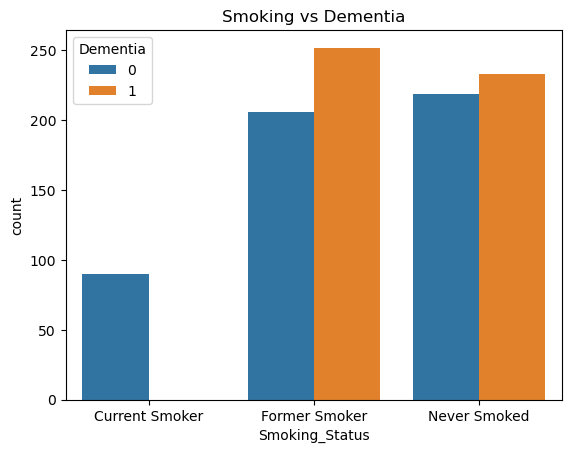

In [25]:
# to be removed 
sns.countplot(x='Smoking_Status', hue='Dementia', data=df)
plt.title("Smoking vs Dementia")
plt.show()

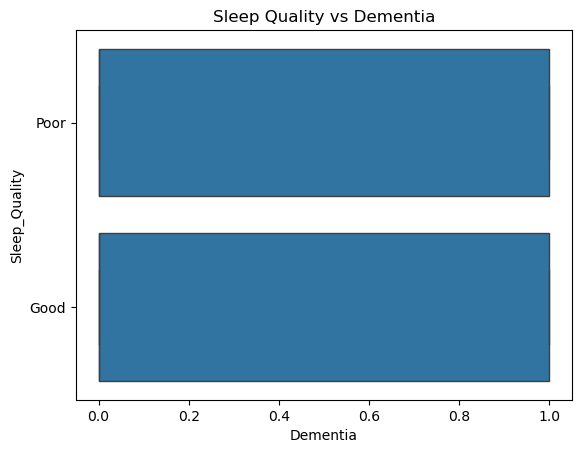

In [27]:
# to be removed 
sns.boxplot(x='Dementia', y='Sleep_Quality', data=df)
plt.title("Sleep Quality vs Dementia")
plt.show()

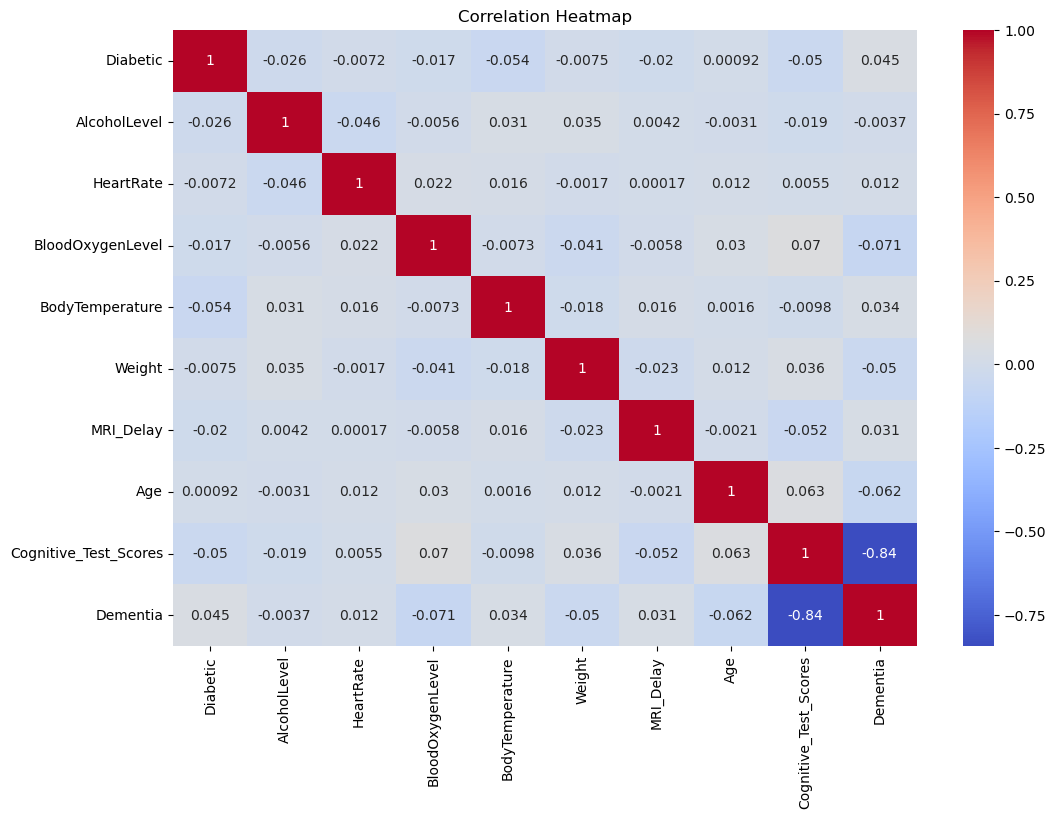

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()